<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/19_GBM_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradient Boosting Machines(GBM)로 TSLA 방향성 예측 (분류)
이 노트북은 다음 거래일의 **상승/하락(이진 분류)**을 예측합니다.
시계열에서는 **시간 순서 보존(train→test)**과 **정보누수 방지**가 핵심입니다.


### 📊 GBM (Gradient Boosting Machine) 구조 시각화
아래 그래프는 GBM이 오차(Residual)를 어떻게 줄여나가는지 보여주는 개념도입니다.

Tree 1: 최초의 예측을 수행합니다.

Residual 1 (Error): 실제값과 Tree 1의 예측값 사이의 오차(잔차)가 발생합니다.

Tree 2: 이 오차를 학습하여 이전 모델의 실수를 보정합니다.

Final Ensemble: 이렇게 생성된 여러 나무들의 예측치를 학습률(lr)을 곱해 모두 더하여 최종 예측을 완성합니다.

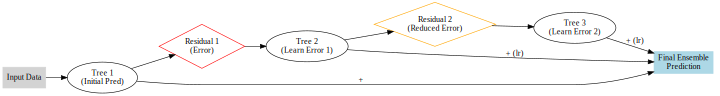

In [13]:
import graphviz

# Digraph(방향성 그래프) 객체 생성
dot = graphviz.Digraph('GBM_Concept', comment='GBM Structure')
dot.attr(rankdir='LR', size='10')

# 노드 정의 (Nodes)
dot.node('Data', 'Input Data', shape='box', style='filled', color='lightgrey')
dot.node('T1', 'Tree 1\n(Initial Pred)', shape='ellipse')
dot.node('E1', 'Residual 1\n(Error)', shape='diamond', color='red')
dot.node('T2', 'Tree 2\n(Learn Error 1)', shape='ellipse')
dot.node('E2', 'Residual 2\n(Reduced Error)', shape='diamond', color='orange')
dot.node('T3', 'Tree 3\n(Learn Error 2)', shape='ellipse')
dot.node('Final', 'Final Ensemble\nPrediction', shape='box', style='filled', color='lightblue')

# 연결 관계 정의 (Edges)
dot.edge('Data', 'T1')
dot.edge('T1', 'E1')
dot.edge('E1', 'T2')
dot.edge('T2', 'E2')
dot.edge('E2', 'T3')
dot.edge('T1', 'Final', label='+')
dot.edge('T2', 'Final', label='+ (lr)')
dot.edge('T3', 'Final', label='+ (lr)')

display(dot)

### 🧠 GBM 모델 훈련 코드 상세 설명

훈련 코드에서 사용된 `GradientBoostingClassifier`의 주요 설정값(하이퍼파라미터)들의 의미는 다음과 같습니다.

1. **n_estimators=300**
   - **의미**: 사용할 결정 트리의 개수입니다.
   - **설명**: 300개의 나무를 순차적으로 만들어 오차를 보정합니다. 너무 많으면 과적합(Overfitting)이 발생할 수 있고, 너무 적으면 학습이 부족할 수 있습니다.

2. **learning_rate=0.05**
   - **의미**: 학습률 (수식에서의 $\nu$)
   - **설명**: 각 나무가 전체 예측에 기여하는 정도를 조절합니다. 일반적으로 학습률을 낮게 설정하고 나무의 개수(n_estimators)를 늘리는 것이 모델 성능 안정화에 도움이 됩니다.

3. **max_depth=2**
   - **의미**: 각 트리의 최대 깊이
   - **설명**: 나무를 얼마나 깊게(복잡하게) 만들지 결정합니다. GBM은 보통 얕은 나무(깊이 2~3)를 여러 개 쌓는 것이 성능이 좋으며, 깊이가 깊어지면 개별 트리가 복잡해져 과적합 위험이 커집니다.

4. **random_state=42**
   - **의미**: 난수 고정값
   - **설명**: 코드를 실행할 때마다 결과가 달라지지 않도록 결과를 고정하는 역할을 합니다.

5. **model.fit(X_train, y_train)**
   - **의미**: 모델 학습 시작
   - **설명**: 준비된 학습 데이터(X_train)와 정답(y_train)을 모델에 주입하여, 과거의 패턴을 통해 내일의 상승/하락을 맞추는 방법을 학습시킵니다.

## 🤖 Gradient Boosting Machine (GBM) 상세 설명

### 1. 알고리즘 개념
GBM은 여러 개의 **약한 학습기(Weak Learner)**, 주로 얕은 결정 트리(Decision Tree)를 순차적으로 결합하여 강력한 예측 모델을 만드는 앙상블 기법입니다.

* **순차적 학습**: 첫 번째 트리가 예측을 하고 남은 **오차(Residual)**를 두 번째 트리가 학습하여 보정합니다. 이 과정을 반복하며 오차를 줄여나갑니다.
* **경사 하강법(Gradient Descent)**: 모델이 예측한 값과 실제 값 사이의 손실 함수(Loss Function)를 최소화하기 위해 기울기(Gradient)를 따라 최적의 파라미터를 찾습니다.

### 2. 주요 수식 (Concept)
모델의 최종 예측값 $F_M(x)$는 다음과 같이 정의됩니다:

$$F_M(x) = ∑_{m=1}^{M} ν ⋅ h_m(x)$$

- $h_m(x)$: $m$번째 단계에서 학습된 약한 학습기(트리)
- $ν$ (nu): 학습률(Learning Rate), 각 트리의 기여도를 조절하여 과적합을 방지합니다.
- $M$: 생성할 트리의 총 개수

### 3. 구조도
`[데이터] -> [Tree 1] -> (오차 발생) -> [Tree 2 (오차 학습)] -> (오차 감소) -> [Tree 3] ... -> [최종 예측]`

## 0) 환경 준비
```bash
pip install yfinance
```


In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)


## 1) 데이터 수집 (2025-03-30 ~ 2026-03-30, 최근 1년)


In [4]:
df = yf.download("TSLA", start="2025-03-30", end="2026-03-30", auto_adjust=True, progress=False).reset_index()
print("Rows:", len(df))
df.head()


Rows: 247


Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2025-03-31,259.160004,260.559998,243.360001,249.309998,134008900
1,2025-04-01,268.459991,277.450012,259.250000,263.799988,146486900
2,2025-04-02,282.760010,284.989990,251.270004,254.600006,212787800
3,2025-04-03,267.279999,276.299988,261.510010,265.290009,136174300
4,2025-04-04,239.429993,261.000000,236.000000,255.380005,181229400


## 2) 특징 생성 (Feature Engineering)

### 🔍 피처(Feature) 상세 설명
모델의 예측 성능을 높이기 위해 사용된 7가지 기술적 지표의 의미는 다음과 같습니다.

1. ret_lag1 ~ ret_lag10 (Lagged Returns):
   - 설명: 각각 1일 전, 2일 전, 3일 전, 5일 전, 10일 전의 주가 수익률입니다.
   - 의도: 과거의 수익률 패턴이 내일의 방향성에 영향을 주는지 학습합니다 (예: 어제 올랐으면 오늘도 오를까?).

2. ma_gap (MA Cross Over Distance):
   - 계산: (5일 이동평균 / 20일 이동평균) - 1.0
   - 설명: 단기 평단가(5일)와 중기 평단가(20일) 사이의 이격도입니다.
   - 의도: 단기 추세가 장기 추세 대비 얼마나 과열되었는지 또는 골든/데드크로스 근처에 있는지를 나타냅니다.

3. vol10 (Rolling Volatility):
   - 계산: 최근 10일간 수익률의 표준편차(Standard Deviation)
   - 설명: 최근 시장의 변동성(위험도)을 측정합니다.
   - 의도: 시장이 불안정한 상태(고변동성)인지 안정적인 상태(저변동성)인지에 따라 상승 확률이 달라지는지 확인합니다.

In [5]:
# 수익률 계산
df['ret1'] = df['Close'].pct_change()

# 과거 수익률(Lag) 피처 생성
for k in [1,2,3,5,10]:
    df[f'ret_lag{k}'] = df['ret1'].shift(k)

# 이동평균 및 이격도 계산
df['ma5']  = df['Close'].rolling(5).mean()
df['ma20'] = df['Close'].rolling(20).mean()
df['ma_gap'] = (df['ma5'] / df['ma20']) - 1.0

# 10일 변동성 계산
df['vol10'] = df['ret1'].rolling(10).std()

# 결측치 제거
df = df.dropna().reset_index(drop=True)
print('전처리 후 데이터 행 수:', len(df))

전처리 후 데이터 행 수: 228


## 3) 타깃/분할(시간 순서 보존)


In [6]:
# 타깃: 다음날 상승(1) / 하락(0)
df['ret_next'] = df['Close'].pct_change().shift(-1)
df['y_bin'] = (df['ret_next'] > 0).astype(int)
df = df.dropna().reset_index(drop=True)

features = ['ret_lag1','ret_lag2','ret_lag3','ret_lag5','ret_lag10','ma_gap','vol10']
X = df[features]
y = df['y_bin']

# 시간 순서 보존 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (181, 7) Test: (46, 7)


## 4) 모델 학습


In [7]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)
model.fit(X_train, y_train)


GradientBoostingClassifier(learning_rate=0.05, max_depth=2, n_estimators=300,
                           random_state=42)

## 5) 평가


Accuracy: 0.5435
ROC-AUC : 0.5133

Classification report:
              precision    recall  f1-score   support

           0     0.5200    0.5909    0.5532        22
           1     0.5714    0.5000    0.5333        24

    accuracy                         0.5435        46
   macro avg     0.5457    0.5455    0.5433        46
weighted avg     0.5468    0.5435    0.5428        46



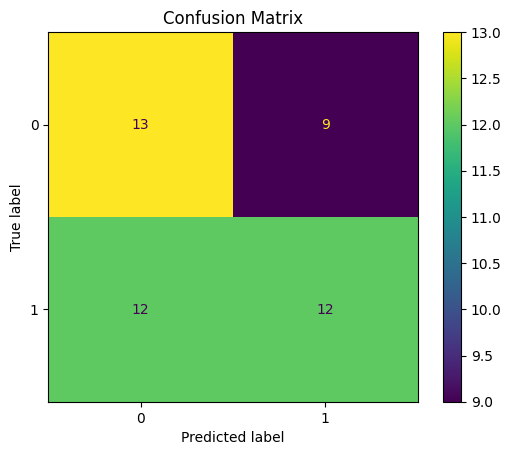

In [8]:
y_pred = model.predict(X_test)

# 확률 예측이 가능한 모델이면 AUC도 계산
if hasattr(model, "predict_proba"):
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
else:
    y_proba = None
    auc = None

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
if auc is not None:
    print(f"ROC-AUC : {auc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(values_format="d")
plt.title("Confusion Matrix")
plt.show()


## 6) 방향 요약 + 다음 거래일 예측


In [9]:
import numpy as np
import pandas as pd

prediction_counts = np.bincount(y_pred)
print(f"Predicted Down (하락): {prediction_counts[0] if len(prediction_counts) > 0 else 0} 건")
print(f"Predicted Up (상승): {prediction_counts[1] if len(prediction_counts) > 1 else 0} 건")

last_day_features = X.iloc[-1].values.reshape(1, -1)
next_day_prediction = model.predict(last_day_features)
prediction_label = "상승 (Up)" if int(next_day_prediction[0]) == 1 else "하락 (Down)"

last_date_in_df = df['Date'].iloc[-1]
predicted_date = last_date_in_df + pd.Timedelta(days=1)

print(f"다음 거래일 예측 (날짜: {predicted_date.strftime('%Y-%m-%d')}): {prediction_label}")


Predicted Down (하락): 25 건
Predicted Up (상승): 21 건
다음 거래일 예측 (날짜: 2026-03-24): 하락 (Down)


## ✅ 마지막 시각화(결과를 눈으로 확인)
마지막 셀은 반드시 그래프가 출력되도록 구성했습니다.

 모델의 '피처 중요도(Feature Importances)'를 보여주는 하나의 막대 그래프만 출력됩니다. 이 그래프는 모델이 예측을 수행할 때 어떤 피처(예측 변수)를 가장 중요하게 고려했는지 시각적으로 보여줍니다.




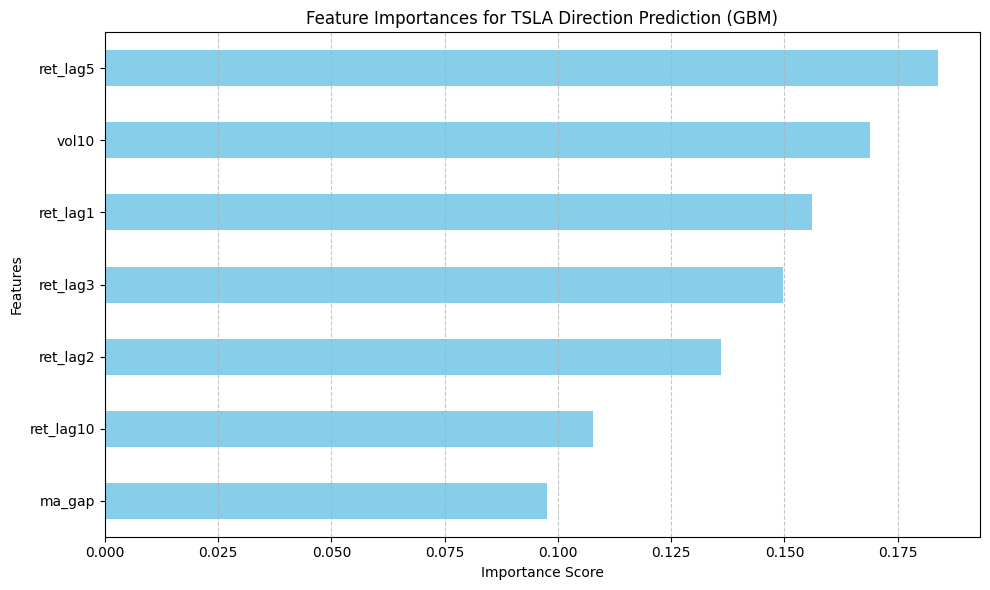

--- 해석 가이드 ---
1. 막대가 길수록 모델이 내일의 주가 방향을 결정할 때 더 많이 참고한 지표입니다.
2. 만약 ma_gap이 높다면, 현재의 추세 이격도가 상승/하락 판단의 핵심 근거가 됨을 의미합니다.
3. 특정 lag 수익률이 높다면, 과거의 특정 시점 패턴이 반복되는 경향이 있음을 시사합니다.


In [10]:
# Feature importance 시각화
# 한글 깨짐 방지를 위해 모든 텍스트를 영어로 표기합니다.
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='skyblue')
plt.title('Feature Importances for TSLA Direction Prediction (GBM)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print('--- 해석 가이드 ---')
print('1. 막대가 길수록 모델이 내일의 주가 방향을 결정할 때 더 많이 참고한 지표입니다.')
print('2. 만약 ma_gap이 높다면, 현재의 추세 이격도가 상승/하락 판단의 핵심 근거가 됨을 의미합니다.')
print('3. 특정 lag 수익률이 높다면, 과거의 특정 시점 패턴이 반복되는 경향이 있음을 시사합니다.')

## ✅ 요약(3줄)
1) 분류는 ‘가격’을 맞추는 것이 아니라 ‘방향(Up/Down)’을 예측합니다.
2) 시계열에서는 **시간 분할**과 **누수 방지**가 성능보다 먼저입니다.
3) 정확도만 보지 말고 AUC/혼동행렬/기준선과 함께 해석하세요.
